<a href="https://colab.research.google.com/github/priyamaninagaragonda-bot/CodeAlpha_Task2_EDA/blob/main/Task2_EDA_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis of Titanic Dataset

## Internship Task 2

### Objective
To explore and analyze the Titanic dataset, identify patterns and trends, handle missing data, and understand factors related to passenger survival.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Task 2 - Exploratory Data Analysis")
print("Python is ready!")

Task 2 - Exploratory Data Analysis
Python is ready!


In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and Columns: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Dataset Information")
print("-------------------")

print("Number of rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset Information
-------------------
Number of rows and columns: (891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
print("Basic Statistics")
print("----------------")

df.describe()

Basic Statistics
----------------


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print("Categorical Data Summary")
print("------------------------")

print("\nGender:")
print(df["Sex"].value_counts())

print("\nPassenger Class:")
print(df["Pclass"].value_counts())

print("\nSurvival:")
print(df["Survived"].value_counts())

print("\nEmbarked:")
print(df["Embarked"].value_counts())

Categorical Data Summary
------------------------

Gender:
Sex
male      577
female    314
Name: count, dtype: int64

Passenger Class:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Survival:
Survived
0    549
1    342
Name: count, dtype: int64

Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


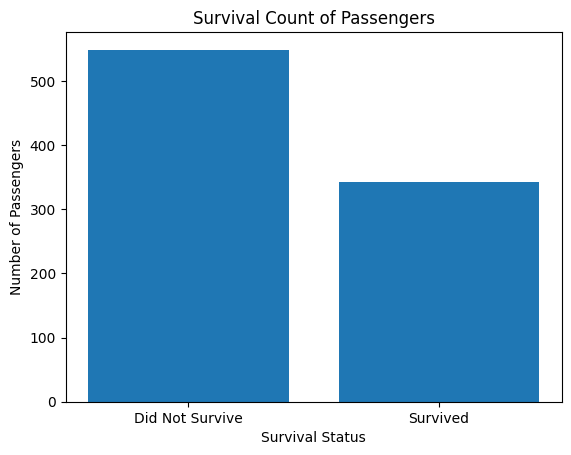

In [6]:
import matplotlib.pyplot as plt

survival_counts = df["Survived"].value_counts()

plt.bar(["Did Not Survive", "Survived"], survival_counts)
plt.title("Survival Count of Passengers")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.show()

Survival by Gender:
Survived    0    1
Sex               
female     81  233
male      468  109


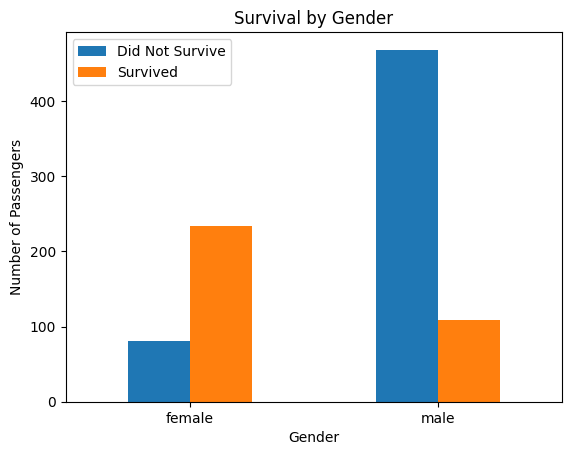

In [7]:
survival_gender = pd.crosstab(df["Sex"], df["Survived"])

print("Survival by Gender:")
print(survival_gender)

survival_gender.plot(kind="bar")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])
plt.show()

Survival by Passenger Class:
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


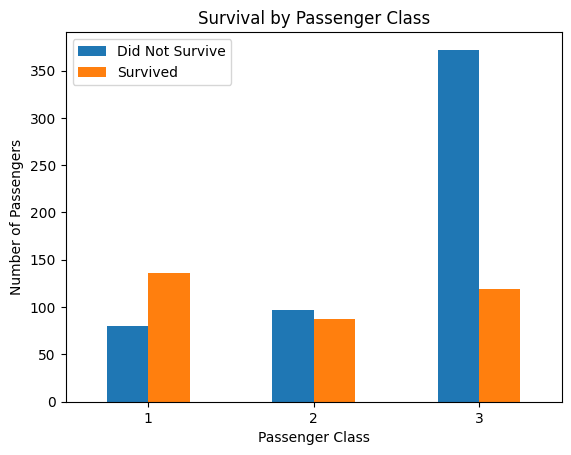

In [8]:
survival_class = pd.crosstab(df["Pclass"], df["Survived"])

print("Survival by Passenger Class:")
print(survival_class)

survival_class.plot(kind="bar")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])
plt.show()

In [9]:
# Make a copy of the dataset
df_clean = df.copy()

# Fill missing Age values with the median age
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Fill missing Embarked values with the most common value
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Drop Cabin because most values are missing
df_clean = df_clean.drop(columns=["Cabin"])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


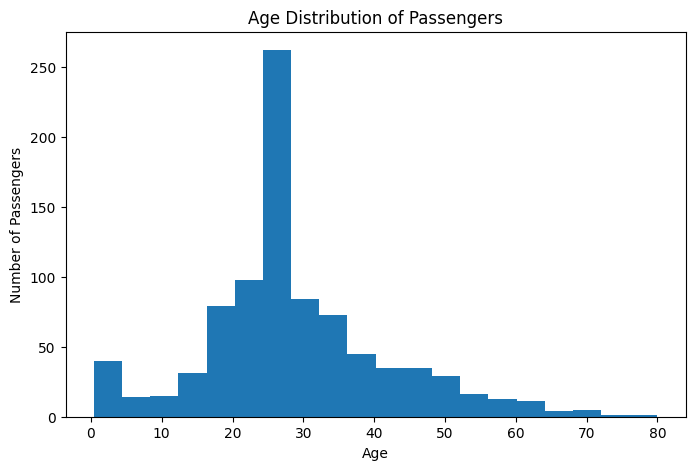

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df_clean["Age"], bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

<Figure size 800x500 with 0 Axes>

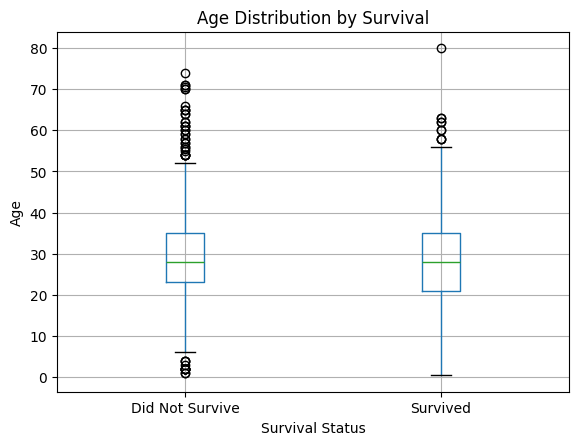

In [11]:
plt.figure(figsize=(8, 5))

df_clean.boxplot(column="Age", by="Survived")

plt.title("Age Distribution by Survival")
plt.suptitle("")
plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.xticks([1, 2], ["Did Not Survive", "Survived"])

plt.show()

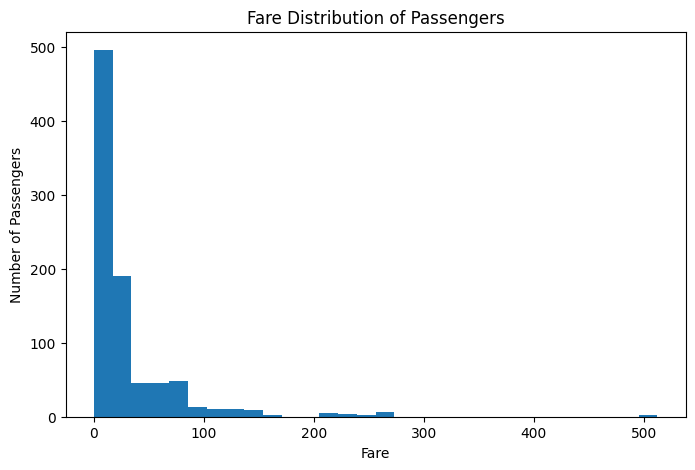

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(df_clean["Fare"], bins=30)

plt.title("Fare Distribution of Passengers")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

<Figure size 800x500 with 0 Axes>

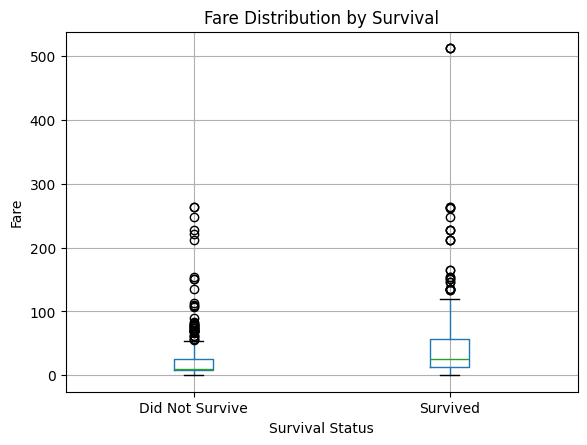

In [13]:
plt.figure(figsize=(8, 5))

df_clean.boxplot(column="Fare", by="Survived")

plt.title("Fare Distribution by Survival")
plt.suptitle("")
plt.xlabel("Survival Status")
plt.ylabel("Fare")
plt.xticks([1, 2], ["Did Not Survive", "Survived"])

plt.show()

In [14]:
print("Survival Rate by Gender:")
print(df_clean.groupby("Sex")["Survived"].mean() * 100)

print("\nSurvival Rate by Passenger Class:")
print(df_clean.groupby("Pclass")["Survived"].mean() * 100)

Survival Rate by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival Rate by Passenger Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [15]:
survival_gender_class = df_clean.groupby(["Sex", "Pclass"])["Survived"].mean() * 100

print("Survival Rate by Gender and Passenger Class:")
print(survival_gender_class)

Survival Rate by Gender and Passenger Class:
Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64


In [16]:
print("========== EDA SUMMARY ==========")

print("\nDataset Size:")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nSurvival Rate:")
print(df_clean["Survived"].mean() * 100, "%")

print("\nAverage Age:")
print(df_clean["Age"].mean())

print("\nAverage Fare:")
print(df_clean["Fare"].mean())

print("\nEDA completed successfully!")

========== EDA SUMMARY ==========

Dataset Size:
Rows: 891
Columns: 11

Survival Rate:
38.38383838383838 %

Average Age:
29.36158249158249

Average Fare:
32.204207968574636

EDA completed successfully!


## Questions for Analysis

1. What is the overall survival rate of passengers?
2. How does survival differ between male and female passengers?
3. Does passenger class affect survival?
4. What is the age distribution of passengers?
5. Is there a relationship between age and survival?
6. Is there a relationship between fare and survival?
7. How do gender and passenger class together affect survival?

## Findings and Insights

- The dataset contains passenger information such as age, gender, passenger class, fare, and survival status.
- Some values were missing in the Age, Cabin, and Embarked columns.
- Missing Age values were filled using the median age.
- Missing Embarked values were filled using the most common value.
- The Cabin column was removed because it contained a large number of missing values.
- Survival rates differed between male and female passengers.
- Survival rates also differed across passenger classes.
- Age and fare distributions showed variation among passengers.
- The analysis of gender and passenger class showed that these factors were associated with differences in survival rates.

## Conclusion

The Exploratory Data Analysis of the Titanic dataset helped identify important patterns in passenger survival. The dataset was inspected, missing values were handled, and statistical analysis and visualizations were used to understand the data. Gender and passenger class showed noticeable differences in survival rates. Overall, the analysis demonstrates how EDA can be used to understand a dataset, identify data-quality issues, and discover meaningful patterns.